<a href="https://colab.research.google.com/github/slchaturya-bit/Seasonal-Agriculture-Performance-Analysis-/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files


# Upload the CSV file
uploaded = files.upload()

# Load the uploaded CSV
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

df.head()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [40]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [3]:
df.shape

(4000, 28)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [5]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [41]:
df.isnull().mean()*100

,0
Farm_ID,0.0
State,0.0
District,0.0
Crop,0.0
Season,0.0
Farm_Area_Hectares,0.0
Rainfall_mm,0.0
Avg_Temperature_C,0.0
Humidity_pct,0.0
Sunlight_Hours_Day,0.0


In [6]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [8]:
# Fill missing values using the median

df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())

df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df['Soil_Moisture_pct'].median()
)

df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(
    df['Yield_Tonnes_Ha'].median()
)

In [9]:
# Check if any missing values remain

df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [43]:
df["Profit_Lakhs"] = df["Profit_INR"].apply(lambda x: x / 100000)

In [42]:
# Fill missing numerical values with median

df["Rainfall_mm"] = df["Rainfall_mm"].fillna(
    df["Rainfall_mm"].median()
)

df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(
    df["Soil_Moisture_pct"].median()
)

df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(
    df["Yield_Tonnes_Ha"].median()
)

In [10]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

In [11]:
# Check the cleaned dataset

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 4000
Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


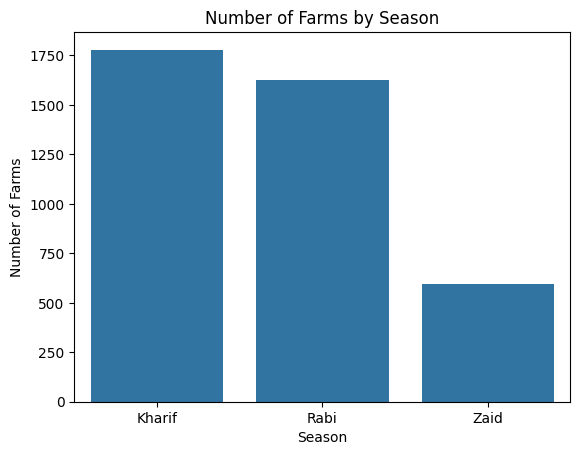

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='Season')

plt.title('Number of Farms by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')
plt.show()

In [13]:
season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,
Kharif,5.63,46.31,178914.65,5.89,54.47
Rabi,5.04,41.49,87689.47,5.19,40.48
Zaid,4.64,38.89,-24804.82,4.41,38.22


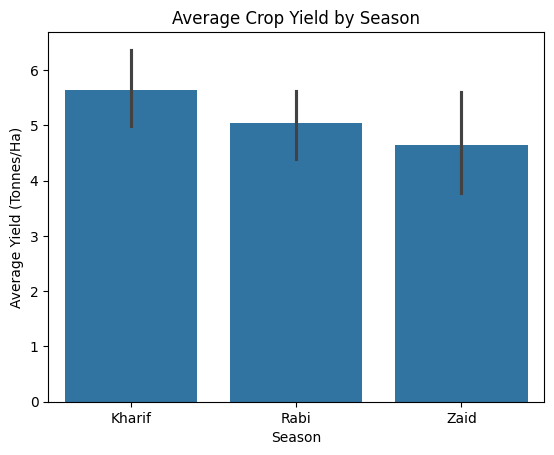

In [14]:
sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='mean'
)

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.show()

In [15]:
best_yield_season = season_summary['Yield_Tonnes_Ha'].idxmax()
best_yield = season_summary['Yield_Tonnes_Ha'].max()

print("Season with highest average yield:", best_yield_season)
print("Average yield:", best_yield, "Tonnes/Ha")

Season with highest average yield: Kharif
Average yield: 5.63 Tonnes/Ha


In [16]:
# Calculate average yield for each crop in each season

crop_season_yield = df.pivot_table(
    index='Crop',
    columns='Season',
    values='Yield_Tonnes_Ha',
    aggfunc='mean'
).round(2)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


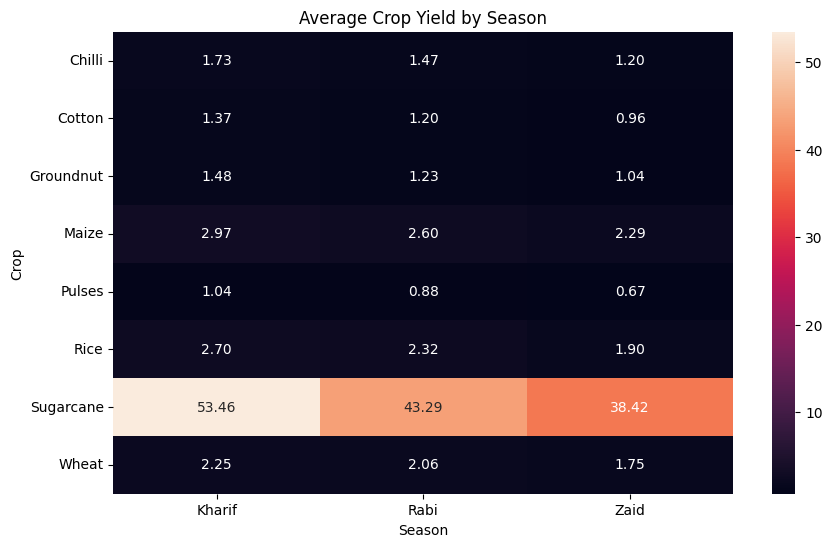

In [17]:
# Heatmap of average crop yield across seasons

plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f'
)

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.show()

In [18]:
# Find the highest-yielding crop in each season

for season in crop_season_yield.columns:
    best_crop = crop_season_yield[season].idxmax()
    best_yield = crop_season_yield[season].max()

    print(
        season,
        "→ Best crop:", best_crop,
        "| Average yield:", best_yield, "Tonnes/Ha"
    )

Kharif → Best crop: Sugarcane | Average yield: 53.46 Tonnes/Ha
Rabi → Best crop: Sugarcane | Average yield: 43.29 Tonnes/Ha
Zaid → Best crop: Sugarcane | Average yield: 38.42 Tonnes/Ha


In [19]:
# Average production for each crop in each season

crop_season_production = df.pivot_table(
    index='Crop',
    columns='Season',
    values='Production_Tonnes',
    aggfunc='mean'
).round(2)

crop_season_production

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,14.46,10.97,9.98
Cotton,10.41,9.44,6.93
Groundnut,10.49,9.06,8.62
Maize,23.35,21.59,17.94
Pulses,8.29,7.20,4.94
Rice,22.45,17.22,15.11
Sugarcane,446.07,365.26,329.56
Wheat,18.31,16.07,14.06


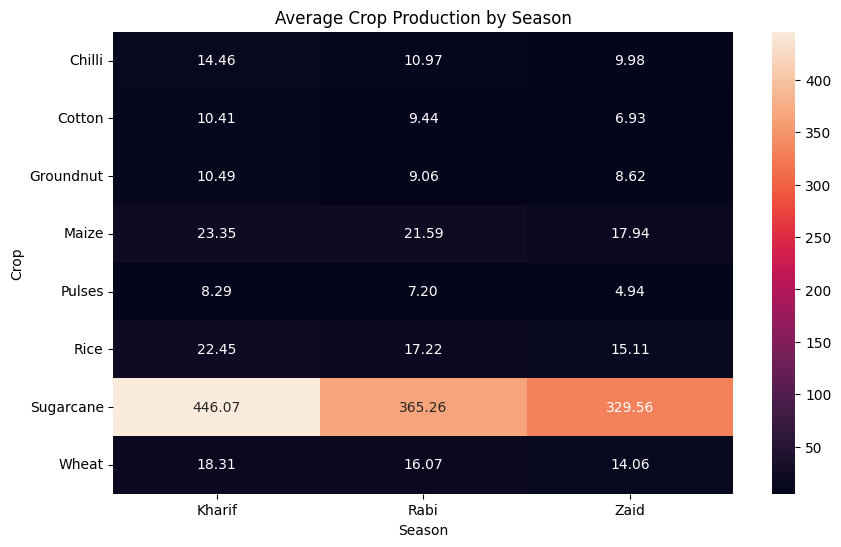

In [20]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season_production,
    annot=True,
    fmt='.2f'
)

plt.title('Average Crop Production by Season')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.show()

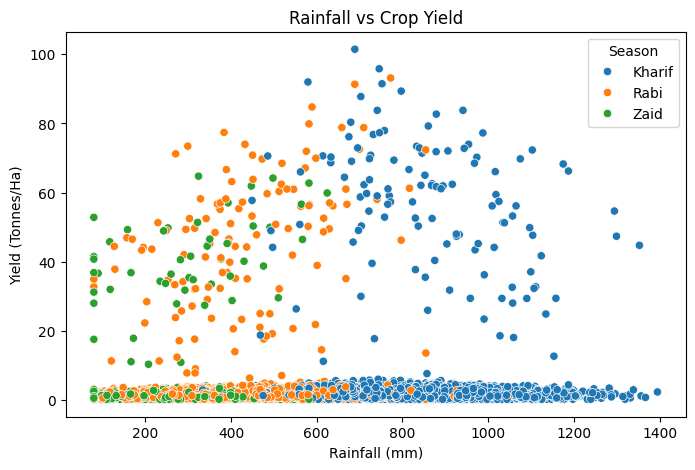

In [21]:
# Relationship between rainfall and crop yield

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [22]:
# Calculate correlation between rainfall and yield

correlation = df['Rainfall_mm'].corr(df['Yield_Tonnes_Ha'])

print("Correlation between Rainfall and Yield:", round(correlation, 3))

Correlation between Rainfall and Yield: 0.031


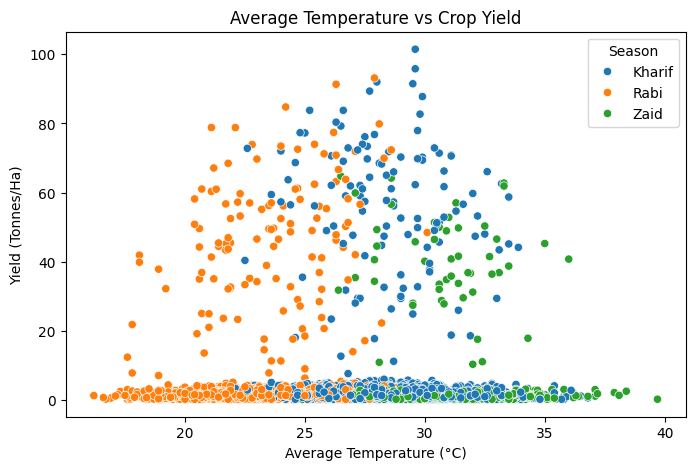

In [23]:
# Relationship between temperature and crop yield

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Average Temperature vs Crop Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [24]:
# Calculate correlation

correlation = df['Avg_Temperature_C'].corr(df['Yield_Tonnes_Ha'])

print("Correlation between Temperature and Yield:", round(correlation, 3))

Correlation between Temperature and Yield: 0.01


In [25]:
# Average profit by season

profit_season = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

print(profit_season)

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


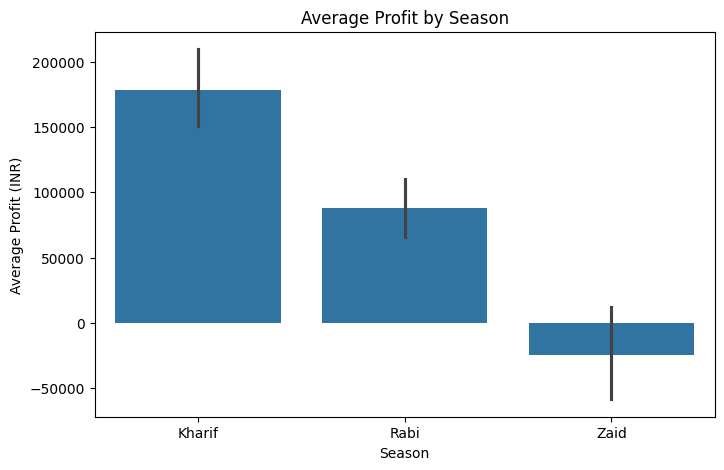

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_INR',
    estimator='mean'
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.show()

In [27]:
best_profit_season = profit_season.idxmax()
best_profit = profit_season.max()

print("Highest profit season:", best_profit_season)
print("Average profit:", round(best_profit, 2), "INR")

Highest profit season: Kharif
Average profit: 178914.65 INR


In [28]:
# Average water efficiency by irrigation method

water_efficiency = df.groupby(
    'Irrigation_Method'
)['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False)

water_efficiency.round(2)

,Water_Efficiency_t_per_1000m3
Irrigation_Method,
Rainfed,7.56
Drip,6.27
Sprinkler,4.67
Flood,3.44


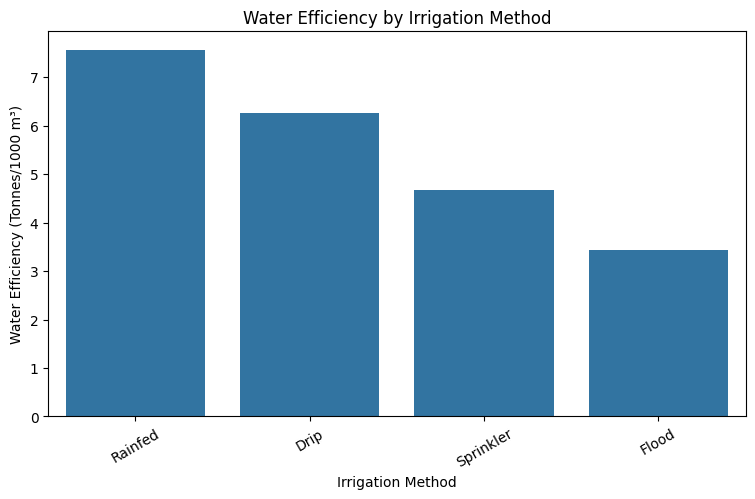

In [29]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=water_efficiency.index,
    y=water_efficiency.values
)

plt.title('Water Efficiency by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Efficiency (Tonnes/1000 m³)')
plt.xticks(rotation=30)
plt.show()

In [30]:
best_irrigation = water_efficiency.idxmax()

print("Highest water efficiency:", best_irrigation)
print(
    "Average efficiency:",
    round(water_efficiency.max(), 2),
    "Tonnes/1000 m³"
)

Highest water efficiency: Rainfed
Average efficiency: 7.56 Tonnes/1000 m³


In [32]:
best_irrigation = water_efficiency.idxmax()

print("Highest water efficiency:", best_irrigation)
print(
    "Average efficiency:",
    round(water_efficiency.max(), 2),
    "Tonnes/1000 m³"
)

Highest water efficiency: Rainfed
Average efficiency: 7.56 Tonnes/1000 m³


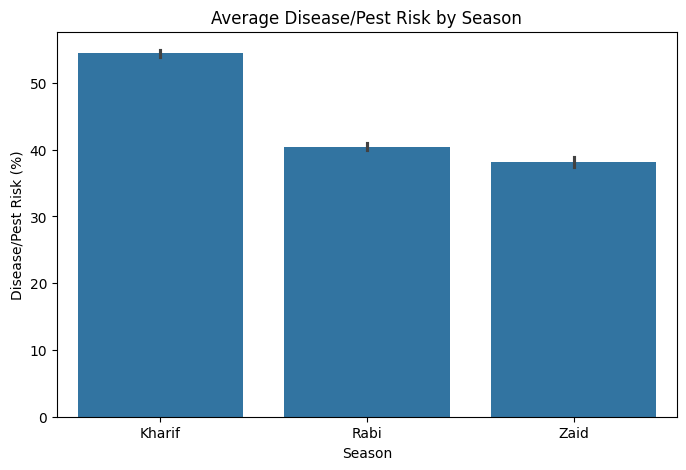

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Disease_Pest_Risk_pct',
    estimator='mean'
)

plt.title('Average Disease/Pest Risk by Season')
plt.xlabel('Season')
plt.ylabel('Disease/Pest Risk (%)')
plt.show()

In [33]:
# Average profit by state

state_profit = df.groupby(
    'State'
)['Profit_INR'].mean().sort_values(ascending=False)

state_profit.round(2)

,Profit_INR
State,
Punjab,136025.64
Maharashtra,135428.86
Karnataka,119422.34
Tamil Nadu,117744.75
Gujarat,117568.24
Telangana,108829.62
Madhya Pradesh,86840.76
Andhra Pradesh,73453.53


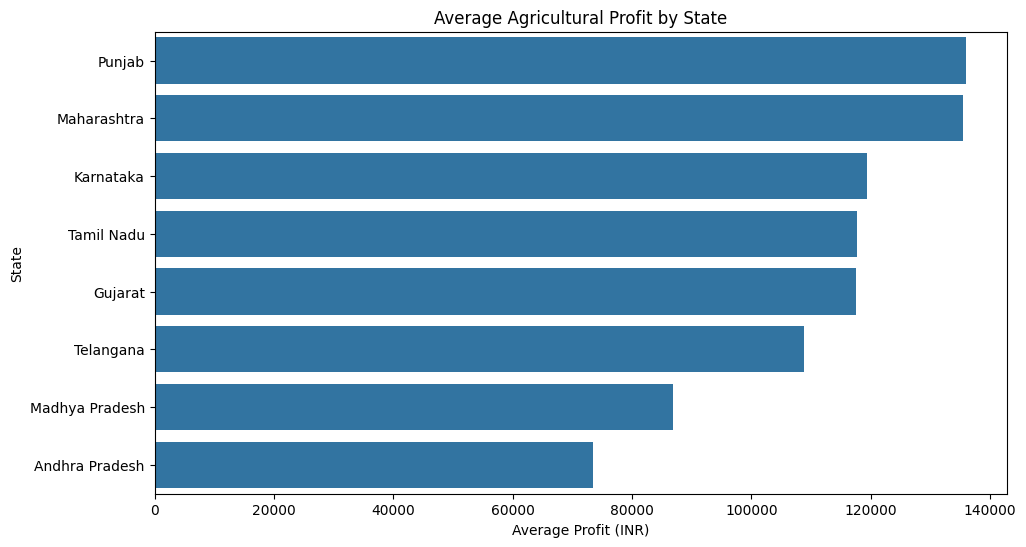

In [34]:
plt.figure(figsize=(11, 6))

sns.barplot(
    x=state_profit.values,
    y=state_profit.index
)

plt.title('Average Agricultural Profit by State')
plt.xlabel('Average Profit (INR)')
plt.ylabel('State')
plt.show()

In [35]:
# Select important numerical variables

correlation_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Rainfall_mm,1.00,0.20,0.52,0.51,0.03,0.02,0.11,0.06,0.62
Avg_Temperature_C,0.20,1.00,0.14,0.08,0.01,0.01,0.01,0.01,0.25
Humidity_pct,0.52,0.14,1.00,0.45,0.01,0.00,0.06,0.03,0.55
Soil_Moisture_pct,0.51,0.08,0.45,1.00,0.01,0.00,0.09,0.03,0.38
Yield_Tonnes_Ha,0.03,0.01,0.01,0.01,1.00,0.88,0.49,0.91,0.01
Production_Tonnes,0.02,0.01,0.00,0.00,0.88,1.00,0.55,0.81,0.01
Profit_INR,0.11,0.01,0.06,0.09,0.49,0.55,1.00,0.49,0.07
Water_Efficiency_t_per_1000m3,0.06,0.01,0.03,0.03,0.91,0.81,0.49,1.00,0.03
Disease_Pest_Risk_pct,0.62,0.25,0.55,0.38,0.01,0.01,0.07,0.03,1.00


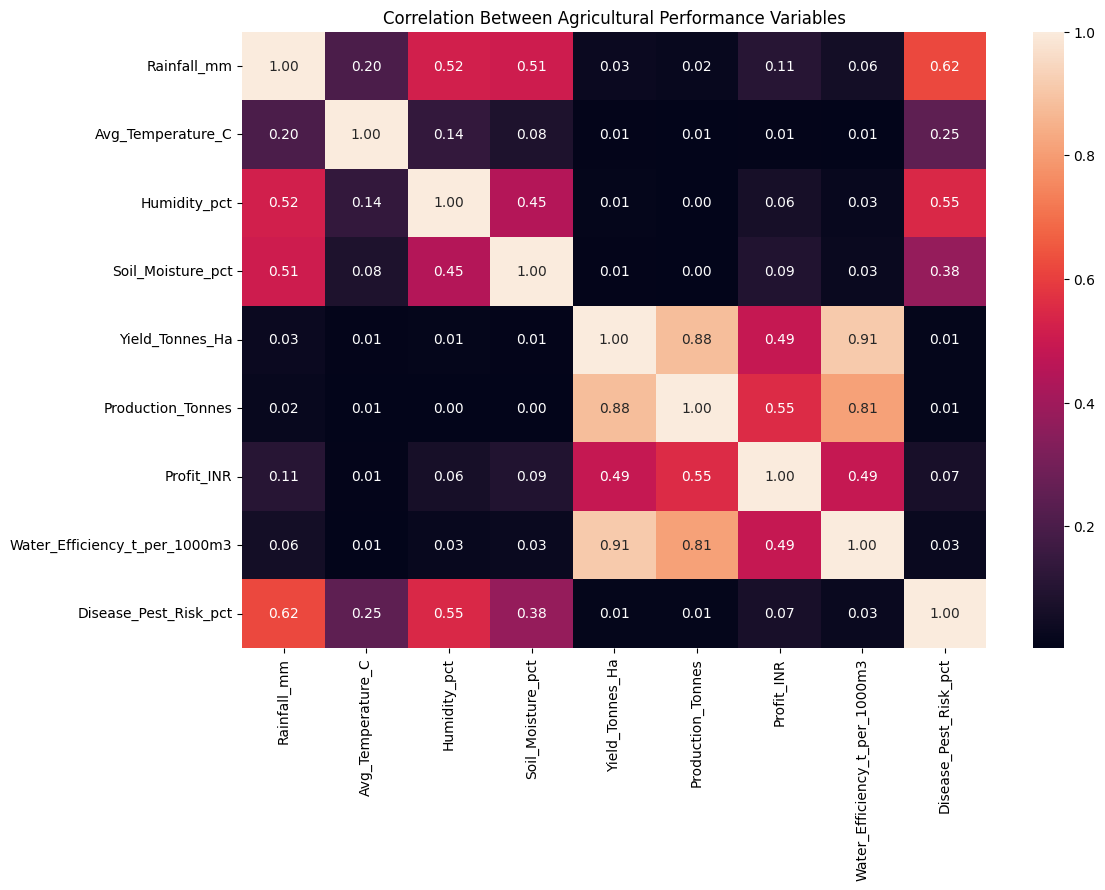

In [36]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Between Agricultural Performance Variables')
plt.show()

In [ ]:
from scipy.stats import f_oneway

# Separate yield values by season

kharif_yield = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi_yield = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid_yield = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

# Perform one-way ANOVA

f_stat, p_value = f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("F-statistic:", round(f_stat, 3))
print("P-value:", p_value)

In [ ]:
# Profit values by season

kharif_profit = df[df['Season'] == 'Kharif']['Profit_INR']
rabi_profit = df[df['Season'] == 'Rabi']['Profit_INR']
zaid_profit = df[df['Season'] == 'Zaid']['Profit_INR']

# Perform ANOVA

f_stat_profit, p_value_profit = f_oneway(
    kharif_profit,
    rabi_profit,
    zaid_profit
)

print("F-statistic:", round(f_stat_profit, 3))
print("P-value:", p_value_profit)